# ToBigs 정규세션 5주차 XAI 과제


# 1. Lime

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5aca4a92d32b080dd10dea0671afc73057691faa320e4d44ac23109d19d5dc32
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [3]:
# features
print(X.info())
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=data.feature_names,
    class_names=data.target_names,
    mode='classification'
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba,
    num_features=5 # 상위 5개 주요 feature만
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

실제 라벨: benign
모델의 예측 확률: [[0.03 0.97]]


Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답:

LIME
* 복잡한 블랙박스 모델 전체를 한꺼번에 해석하려는 게 아니라, 특정 입력 하나 주변에서만 모델이 어떻게 판단했는지를 설명하는 방법
* “전역적으로는 복잡한 모델이라도, 어떤 한 데이터 근처의 아주 작은 구간에서는 단순한 모델로 근사할 수 있다"

동작과정
* 설명할 원본 입력 하나를 선택하여 -> 원본 특징을 무작위로 껐다켜서 수많은 실험용 가짜 샘플을 생성.
* 이 변형 샘플들을 원래 블랙박스 모델에 넣어 예측값을 얻음.
* 원본 입력과 얼마나 가까운 샘플인지 계산해 가중치를 부여
* 이 가중치가 반영된 단순한 해석 가능한 모델(surrogate model)을 학습
* 이 단순 모델의 계수를 바탕으로 중요한 특징을 설명한다.


Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답: LIME에서 surrogate model은 블랙박스 모델을 대신해서, 특정 입력 주변에서만 설명을 제공하는 간단한 대리 모델이다. LIME은 복잡한 모델을 직접 설명하려 하지 않고, 원본 데이터 근처에서의 행동만 따로 떼어내어 해석 가능한 단순 모델로 근사한다. 이때 사용되는 것이 surrogate model이다.

---

#2. SHAP

In [5]:
!pip install shap

### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

--- 전체 데이터의 특성 중요도 (Summary Plot) ---


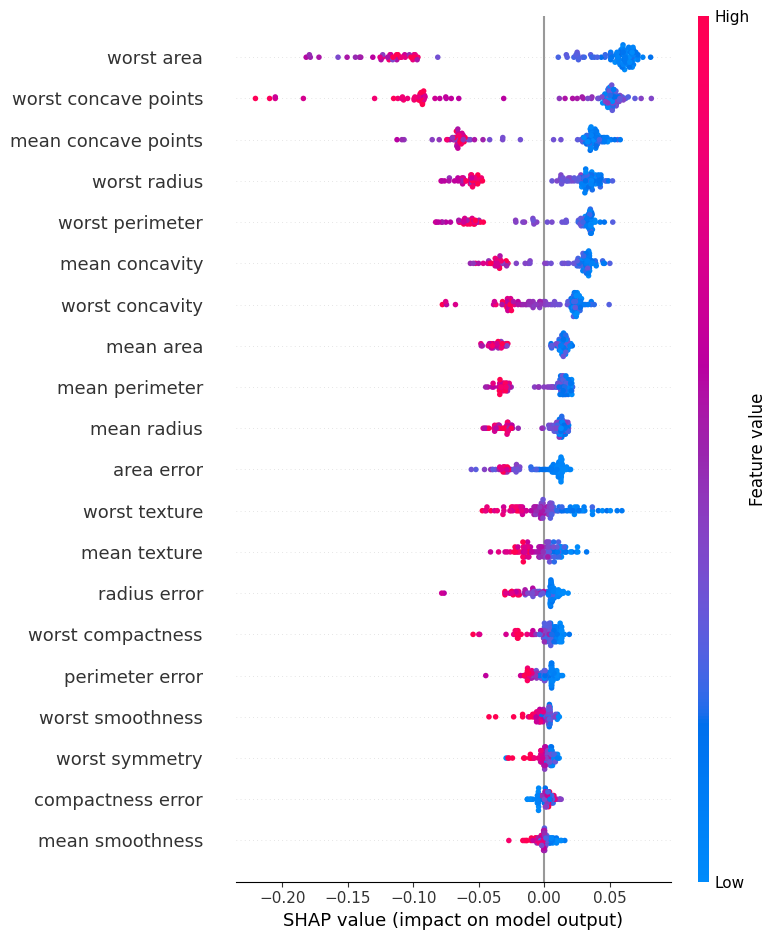

In [6]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)

# 결과 시각화 준비
if isinstance(shap_values, list):

    target_shap_values = shap_values[1]
    base_value = explainer_shap.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3. SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답: SHAP value는 특정 특성이 모델의 예측값을 기준값(base value)에서 얼마나, 어느 방향으로 움직였는지를 나타낸다. SHAP value의 부호는 “이 특성이 특정 클래스의 출력값을 기준으로, 그 예측을 밀어 올렸는지, 끌어내렸는지” 를 보여준다.


Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답:
* 기존 Random Forest 같은 Tree 기반 모델에서 사용하는 feature importance는 보통 각 특성이 분할(split)에 사용될 때 불순도(impurity)를 얼마나 줄였는가를 기준으로 계산된다. 여기서 불순도 척도로 Gini index나 entropy가 사용된다.

* 반면 SHAP의 feature importance는
각 특성이 개별 예측에 실제로 얼마나 기여했는지를 Shapley value로 계산하고, 이를 전체 데이터에 대해 평균 내어 중요도를 본다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 94.1MB/s]


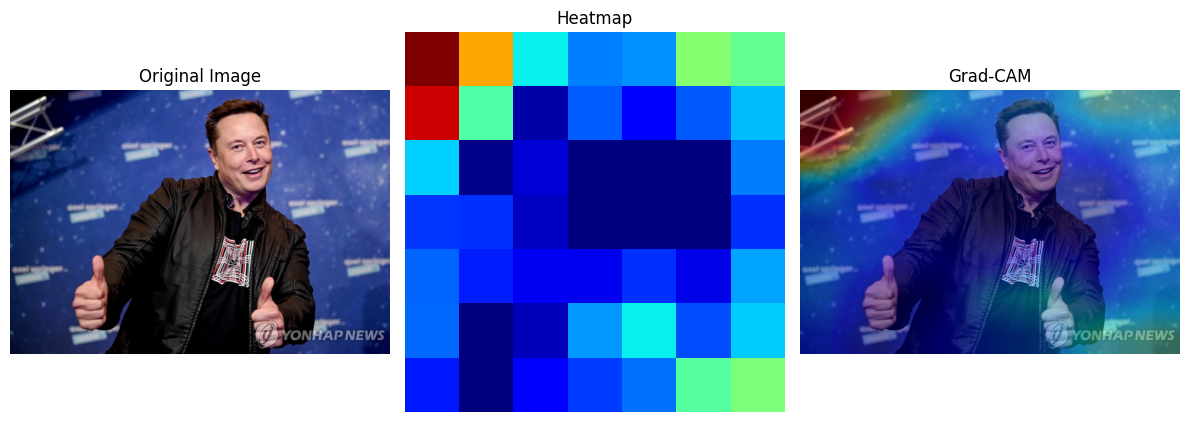

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 그래디언트와 특성 맵을 저장할 변수
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward()

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

# 특성 맵과 가중치 결합
heatmap = torch.sum(weights * activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본과 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답: Grad-CAM이 마지막 컨볼루션 층을 주로 사용하는 이유는, 이 층이 공간 정보와 의미 정보 사이의 균형이 가장 잘 잡혀 있는 층이기 때문이다.

CNN의 앞쪽 층은 주로 선, 모서리, 색 변화처럼 아주 기초적인 특징을 본다. 반대로 뒤쪽으로 갈수록 더 복잡한 의미, 즉 물체의 부분이나 클래스와 관련된 고수준 특징을 학습한다. 그런데 완전 마지막의 fully connected 층까지 가버리면, 어떤 위치에서 그런 특징이 나왔는지에 대한 공간적 정보가 많이 사라진다.

따라서 너무 앞층은 의미가 약하고, 너무 뒷층은 위치 정보가 약하기 때문에, 마지막 컨볼루션 층이 가장 적절한 선택인 것이다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답: 붉게 표시되는 영역은 보통 모델이 특정 클래스라고 판단할 때 더 중요하게 참고한 부분을 의미한다. 해당 클래스의 점수를 높이는 데 상대적으로 더 크게 작용한 이미지 영역이며, 이는 반드시 “사람이 생각하는 정답 객체 전체”와 완전히 일치하는 것은 아니다.

Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답: Grad-CAM heatmap은 모델이 중요하게 본 영역을 어느 정도 보여줄 수는 있지만, 항상 이미지의 진짜 중요한 객체를 정확히 담는다고 볼 수는 없다.

1. 모델이 객체 자체가 아니라 배경 단서를 학습했을 수 있다.

2. Grad-CAM은 위치를 대략적으로 보여주는 방법이지, 정밀한 분할 결과가 아니다.
마지막 컨볼루션 층의 feature map은 해상도가 낮은 편이라서, heatmap도 다소 뭉뚱그려진 형태로 나온다. 그래서 객체의 경계나 세부 부위까지 정확히 짚어주지는 못한다.

3. 특정 클래스 점수에 대한 기여만 반영한다.
Grad-CAM은 “이 클래스 점수를 높인 부분”을 보는 방식이라, 이미지 전체에서 진짜 중요한 객체를 완전하게 설명하기보다 해당 예측에 유리하게 작용한 부분만 강조할 수 있다.

4. 모델이 잘못 학습되었으면 heatmap도 misleading할 수 있다.
설명 기법은 모델을 설명할 뿐, 모델이 옳다고 보장하지는 않는다. 모델이 엉뚱한 패턴을 학습했다면 heatmap 역시 그 엉뚱한 근거를 보여줄 수 있다.

그래서 결론적으로,
Grad-CAM heatmap은 모델이 주목한 대략적인 근거를 보여주는 데는 유용하지만, 그것만 보고 “중요한 객체를 정확히 잡았다”고 단정하면 위험하다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

In [19]:
!pip install requests pillow torchvision

import requests
from io import BytesIO
from PIL import Image
from torchvision import transforms

# 이미지 로드 및 전처리
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
response = requests.get(url)
response.raise_for_status()

print("status:", response.status_code)
print("content-type:", response.headers.get("Content-Type"))

img = Image.open(BytesIO(response.content)).convert("RGB")

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

input_tensor = preprocess(img).unsqueeze(0)
print(input_tensor.shape)

status: 200
content-type: image/jpeg
torch.Size([1, 3, 224, 224])


In [20]:
from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

num_layers: 12
attention shape of one layer: torch.Size([1, 12, 197, 197])


In [22]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [23]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

num_layers: 12
one attention shape: torch.Size([1, 12, 197, 197])


In [24]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [25]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

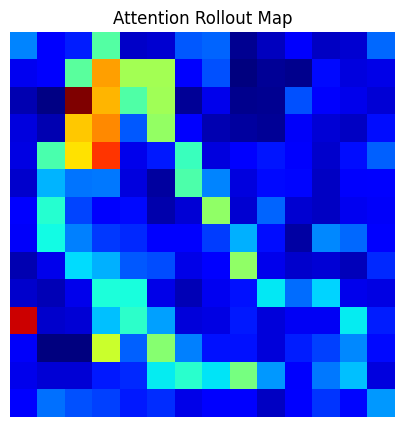

In [26]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



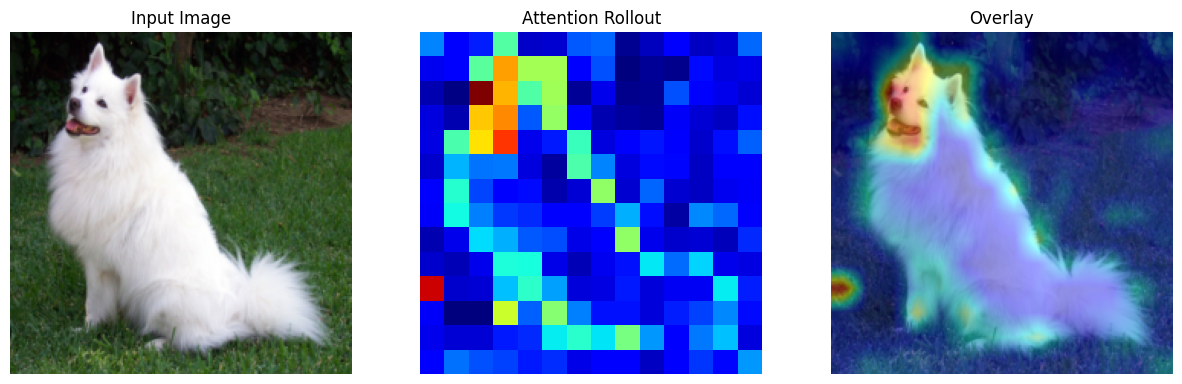

In [27]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답: Attention Rollout을 사용하는 가장 큰 이유는, 한 층의 attention score만 봐서는 최종 예측에 실제로 어떤 정보가 누적되어 전달되었는지 충분히 알기 어렵기 때문이다.

Transformer에서 각 layer의 attention은 독립적으로 한 번만 작동하는 게 아니라, 여러 층을 거치면서 정보가 계속 섞이고 전달된다.
즉, 어떤 token이 마지막 판단에 영향을 주려면 단순히 어느 한 층에서 attention이 높았다는 것만으로는 부족하고, 앞층에서 뒤층까지 정보가 어떻게 흘러왔는지를 같이 봐야 한다.



(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답: 중요한 patch/token만 다시 확대해서 보는 2단계 정밀 분석

ViT에서 attention score가 높은 patch만 따로 골라서,
그 부분을 더 높은 해상도로 다시 인코딩하면 세밀한 특징을 더 잘 잡을 수 있을 것이다. 예를 들어 새의 부리, 자동차 로고, 피부 병변의 경계처럼 작은 차이가 중요한 fine-grained classification 문제에 활용될 수 있을 것이다.